# LAB-P7: El Modelo de Equilibrio General Dinámico Básico (DGE) (Julia)
- **ID de práctica:** LAB-P7-v1.0-julia
- **Capítulo del libro:** Cap. 8 — *An introduction to computational macroeconomics* (Bongers, Gómez y Torres, 2019)
- **Autores:** Dr. Antonio F. Romero Carrasco, Dra. Anelí Bongers
- **Fecha:** 2026-06-20
- **Versión:** 1.0
- **Licencia:** CC BY-SA 4.0 (este notebook) / MIT (el código de `MacroAIComp`)

Objetivo: Desarrollar e interactuar con el modelo canónico de Equilibrio General Dinámico (DGE) en tiempo discreto, resolviendo y comparando la aproximación linealizada de Blanchard-Khan frente a la solución numérica no lineal exacta. Versión en Julia.


> **👋 BIENVENIDA A LA PRÁCTICA - LEER ANTES DE EMPEZAR**
> 
> *   **¿Nunca has usado Jupyter?** No te preocupes. Este cuaderno es interactivo. Haz clic en cualquier celda de código y pulsa **`Shift + Enter`** para ejecutarla. Ve de arriba a abajo en orden.
> *   **¿Se ha congelado o sale un asterisco `[*]` eterno?** Ve al menú superior y dale a `Kernel` ➔ `Restart`.
> *   **El objetivo** de esta práctica es que juegues con la economía. Cambia los números del código que representan impuestos, dinero o tecnología, vuelve a ejecutar y mira los gráficos. ¡No puedes romper nada!
>

### 🕹️ GUÍA RÁPIDA PARA DUMMIES - Equilibrio General Dinámico (DGE)
*   **¿Qué estamos haciendo aquí?** Uniendo a los consumidores, empresas y mercado en un solo gran simulador macroeconómico.
*   **El Ciclo Económico:** Simulamos cómo un shock tecnológico (un aumento repentino de productividad) hace que aumenten a la vez el PIB, la inversión y el consumo.
*   **¡Prueba esto!** Ejecuta la celda del shock tecnológico y observa el gráfico en forma de "joroba" que muestra la propagación de la bonanza en la economía.


In [1]:
# En Google Colab se activarían y descargarían los paquetes necesarios.
# using Pkg; Pkg.activate("."); Pkg.instantiate()


In [2]:
using Pkg
Pkg.activate("../..")

using MacroAIComp
using Plots
using LinearAlgebra
using NLsolve


  Activating project at `C:\Users\AntonioRC\Desktop\PIE`


## 1. El Marco Teórico: DGE y Estabilidad de Blanchard-Khan

El equilibrio de la economía DGE canónica se reduce a:
1. **Dinámica del Capital:**
   $$K_{t+1} = (1-\delta)K_t + A_t K_t^\alpha - C_t$$
2. **Ecuación de Euler:**
   $$C_{t+1} = \beta [ \alpha A_{t+1} K_{t+1}^{\alpha-1} + 1 - \delta ] C_t$$
3. **Proceso TFP:**
   $$\ln(A_t) = \rho \ln(A_{t-1}) + \epsilon_t$$


In [3]:
params = default_calibration(DGEParams)
println(params)


DGEParams(0.35, 0.96, 0.06, 0.8, 1.0)


## 2. Equilibrio de Largo Plazo (Estado Estacionario)


In [4]:
ss = compute_steady_state(params)

println("VALORES DE EQUILIBRIO DE LARGO PLAZO:")
println("  Stock de capital (K*)          : ", ss["K"])
println("  Producción (Y*)                : ", ss["Y"])
println("  Consumo (C*)                   : ", ss["C"])
println("  Inversión bruta (I*)           : ", ss["I"])
println("  Tipo de interés real (R*)      : ", round(ss["R"] * 100, digits=2), "%")


VALORES DE EQUILIBRIO DE LARGO PLAZO:


  Stock de capital (K*)          : 6.698595975419471
  Producción (Y*)                : 1.9457826404789909
  Consumo (C*)                   : 1.5438668819538226
  Inversión bruta (I*)           : 0.4019157585251682
  Tipo de interés real (R*)      : 10.17%


## 3. Verificación frente al oráculo

Comparamos contra los valores reportados en el libro y en `oraculo.md`: $K^* = 6.6986$, $Y^* = 1.9458$.


In [5]:
@assert isapprox(ss["K"], 6.698596; atol=1e-5)
@assert isapprox(ss["Y"], 1.945783; atol=1e-5)
println("OK: coincide con el oráculo.")


OK: coincide con el oráculo.


## 4. Análisis de Shock y Comparación de Solucionadores (Blanchard-Khan vs No Lineal)

Simulamos un shock tecnológico transitorio positivo del $1\%$ en el período $t=2$ (segundo elemento del vector).


Consumo inicial (shock) [BK]        : 1.5488566787261
Consumo inicial (shock) [No Lineal] : 1.5484581612264496


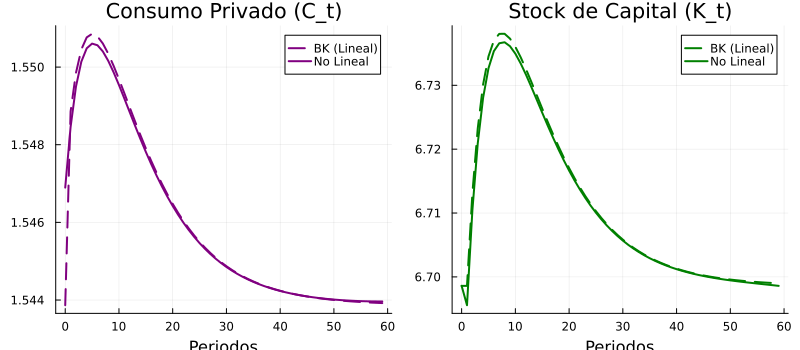

In [6]:
K0 = ss["K"]
T = 60

# Generar trayectoria de shock de TFP
a_hat = zeros(T)
a_hat[1] = 0.0
a_hat[2] = 0.01
for t in 3:T
    a_hat[t] = params.rho * a_hat[t - 1]
end
A_path = exp.(a_hat)

# Resolver lineal (BK) y no lineal
res_bk = solve_blanchard_khan(params, K0, A_path, T)
res_nonlin = solve_nonlinear_simulation(params, K0, A_path, T)

println("Consumo inicial (shock) [BK]        : ", res_bk["C"][2])
println("Consumo inicial (shock) [No Lineal] : ", res_nonlin["C"][2])

# Graficar
t_axis = 0:(T-1)
p1 = plot(t_axis, res_bk["C"], label="BK (Lineal)", color=:purple, linestyle=:dash, lw=2)
plot!(t_axis, res_nonlin["C"], label="No Lineal", color=:purple, lw=2)
title!("Consumo Privado (C_t)")
xlabel!("Periodos")

p2 = plot(t_axis, res_bk["K"], label="BK (Lineal)", color=:green, linestyle=:dash, lw=2)
plot!(t_axis, res_nonlin["K"], label="No Lineal", color=:green, lw=2)
title!("Stock de Capital (K_t)")
xlabel!("Periodos")

plot(p1, p2, layout=(1,2), size=(800, 350))


## 5. Simulación interactiva / modular

Define una función para graficar la respuesta dinámica ante cualquier magnitud del shock sobre la TFP.


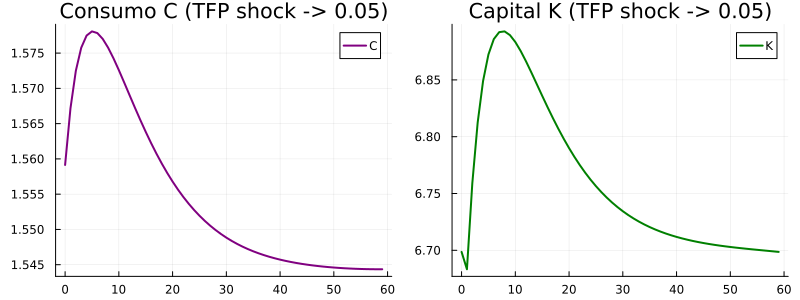

In [7]:
function graficar_shock_tfp(epsilon_val::Float64)
    a_sh = zeros(T)
    a_sh[1] = 0.0
    a_sh[2] = epsilon_val
    for t in 3:T
        a_sh[t] = params.rho * a_sh[t - 1]
    end
    A_sh = exp.(a_sh)
    res_sh = solve_nonlinear_simulation(params, K0, A_sh, T)
    
    p1 = plot(0:(T-1), res_sh["C"], label="C", color=:purple, lw=2)
    title!("Consumo C (TFP shock -> $epsilon_val)")
    
    p2 = plot(0:(T-1), res_sh["K"], label="K", color=:green, lw=2)
    title!("Capital K (TFP shock -> $epsilon_val)")
    
    plot(p1, p2, layout=(1,2), size=(800, 300))
end

# Ejemplo de ejecución
graficar_shock_tfp(0.05)


## 6. Buenas Prácticas Aplicadas y Conclusión

Este modelo dinámico de equilibrio general canónico muestra el efecto hump-shape (respuesta jorobada) en la acumulación de capital físico ante un shock transitorio positivo de productividad, retornando gradualmente al estado de pleno empleo de largo plazo.
